# Brain Tumor CNN Training

This notebook:

1. Imports required libraries
2. Verifies dataset paths
3. Detects tumor classes
4. Counts train/validation/test images
5. Creates validation class folders if needed
6. Moves 20% of training images into validation **only if validation is empty**
7. Visualizes sample MRI images
8. Creates image generators
9. Builds and trains a custom CNN
10. Evaluates the model
11. Plots training history
12. Saves the trained model and class mapping

> **Important:** Run the notebook from the `notebooks/` folder inside the project structure described earlier.


## 1. Import Libraries

In [11]:
import os
import random
import shutil
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Set Random Seeds

In [12]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)


Random seed set to: 42


## 3. Define Dataset Paths

Expected structure:

```text
brain_tumor_project/
├── dataset/
│   └── processed/
│       ├── train/
│       ├── validation/
│       └── test/
├── notebooks/
│   └── 01_brain_tumor_cnn.ipynb
└── models/
```


In [13]:


from pathlib import Path

# PUT YOUR ACTUAL DATASET FOLDER PATH HERE
BASE_DIR = Path(
    r"C:\Users\khush\OneDrive\Desktop\abc\dataset"
)

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "validation"
TEST_DIR = BASE_DIR / "test"

print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)
print("Test path:", TEST_DIR)

print("\nTrain exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())



Train path: C:\Users\khush\OneDrive\Desktop\abc\dataset\train
Validation path: C:\Users\khush\OneDrive\Desktop\abc\dataset\validation
Test path: C:\Users\khush\OneDrive\Desktop\abc\dataset\test

Train exists: True
Validation exists: True
Test exists: True


## 4. Detect Class Names

In [14]:
class_names = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

print("Classes:", class_names)
print("Number of classes:", len(class_names))

assert len(class_names) > 0, "No class folders found inside the training directory."


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


## 5. Count Images

In [15]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def count_images(folder):
    if not folder.exists():
        return 0

    return sum(
        1
        for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )

print("TRAINING DATA")
for class_name in class_names:
    print(f"{class_name}: {count_images(TRAIN_DIR / class_name)}")

print("\nVALIDATION DATA")
for class_name in class_names:
    print(f"{class_name}: {count_images(VAL_DIR / class_name)}")

print("\nTEST DATA")
for class_name in class_names:
    print(f"{class_name}: {count_images(TEST_DIR / class_name)}")


TRAINING DATA
glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400

VALIDATION DATA
glioma: 0
meningioma: 0
notumor: 0
pituitary: 0

TEST DATA
glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


## 6. Create Validation Class Folders

In [16]:
for class_name in class_names:
    validation_class_dir = VAL_DIR / class_name
    validation_class_dir.mkdir(parents=True, exist_ok=True)

print("Validation class folders are ready.")


Validation class folders are ready.


## 7. Create Validation Split

This cell moves 20% of images from each training class into validation.

**Safety behavior:** if validation already contains images, the split is skipped to prevent repeatedly shrinking the training set when the notebook is rerun.


In [17]:
VALIDATION_RATIO = 0.20

existing_validation_images = count_images(VAL_DIR)

if existing_validation_images > 0:
    print(
        f"Validation already contains {existing_validation_images} images. "
        "Skipping split to avoid moving images twice."
    )
else:
    for class_name in class_names:
        train_class_dir = TRAIN_DIR / class_name
        val_class_dir = VAL_DIR / class_name

        images = [
            file
            for file in train_class_dir.iterdir()
            if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
        ]

        random.shuffle(images)

        number_of_validation_images = int(
            len(images) * VALIDATION_RATIO
        )

        validation_images = images[:number_of_validation_images]

        for image_path in validation_images:
            destination = val_class_dir / image_path.name

            # Protect against accidental filename collisions
            if destination.exists():
                raise FileExistsError(
                    f"Destination already exists: {destination}"
                )

            shutil.move(str(image_path), str(destination))

        print(
            f"{class_name}: "
            f"{len(validation_images)} images moved to validation"
        )

    print("\nValidation split completed.")


glioma: 280 images moved to validation
meningioma: 280 images moved to validation
notumor: 280 images moved to validation
pituitary: 280 images moved to validation

Validation split completed.


## 8. Verify Final Dataset Distribution

In [18]:
print("=" * 60)
print("FINAL DATASET DISTRIBUTION")
print("=" * 60)

total_train = 0
total_val = 0
total_test = 0

for class_name in class_names:
    train_count = count_images(TRAIN_DIR / class_name)
    val_count = count_images(VAL_DIR / class_name)
    test_count = count_images(TEST_DIR / class_name)

    total_train += train_count
    total_val += val_count
    total_test += test_count

    print(f"\nClass: {class_name}")
    print(f"Train      : {train_count}")
    print(f"Validation : {val_count}")
    print(f"Test       : {test_count}")

print("\n" + "=" * 60)
print(f"Total Train      : {total_train}")
print(f"Total Validation : {total_val}")
print(f"Total Test       : {total_test}")


FINAL DATASET DISTRIBUTION

Class: glioma
Train      : 1120
Validation : 280
Test       : 400

Class: meningioma
Train      : 1120
Validation : 280
Test       : 400

Class: notumor
Train      : 1120
Validation : 280
Test       : 400

Class: pituitary
Train      : 1120
Validation : 280
Test       : 400

Total Train      : 4480
Total Validation : 1120
Total Test       : 1600


## 9. Display Sample MRI Images

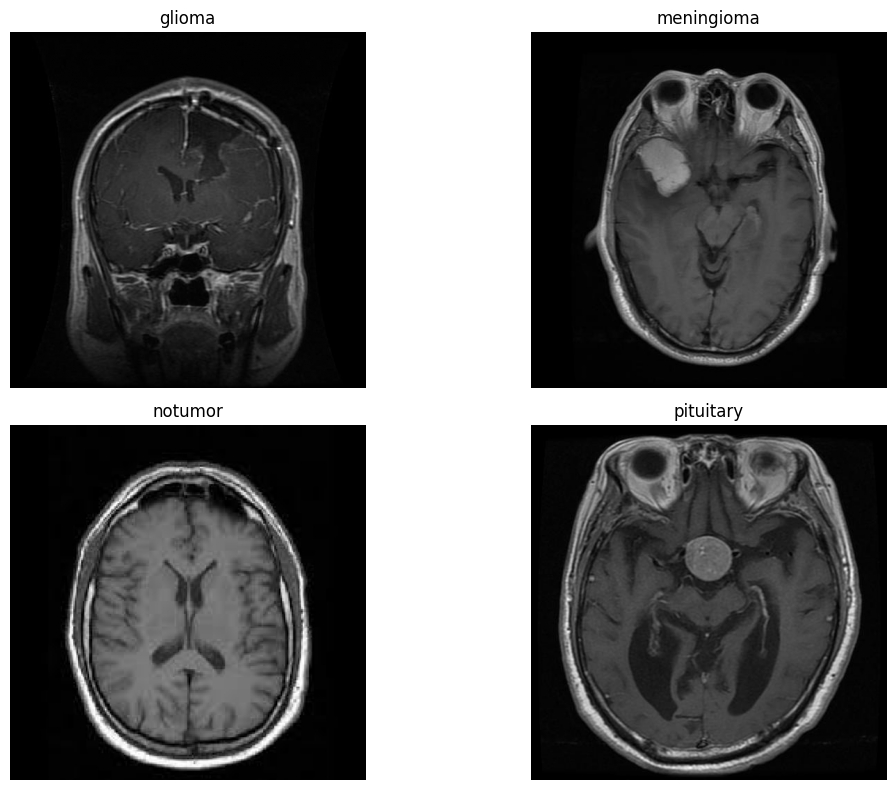

In [19]:
plt.figure(figsize=(12, 8))

for index, class_name in enumerate(class_names):
    class_folder = TRAIN_DIR / class_name

    images = [
        file
        for file in class_folder.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if not images:
        print(f"No images found for class: {class_name}")
        continue

    sample_image = random.choice(images)
    image = plt.imread(sample_image)

    plt.subplot(2, 2, index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 10. Define Image Settings

In [20]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

print("Image size:", IMG_HEIGHT, "x", IMG_WIDTH)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)


Image size: 224 x 224
Batch size: 32
Number of classes: 4


## 11. Create Data Generators

In [21]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)


## 12. Load Training, Validation, and Test Images

In [22]:
train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

validation_generator = validation_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


## 13. Verify and Save Class Mapping

In [23]:
print("Class mapping:", train_generator.class_indices)

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

class_mapping_path = MODELS_DIR / "class_indices.json"

with open(class_mapping_path, "w", encoding="utf-8") as file:
    json.dump(train_generator.class_indices, file, indent=4)

print("Class mapping saved to:", class_mapping_path.resolve())


Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Class mapping saved to: C:\Users\khush\OneDrive\Desktop\abc\models\class_indices.json


## 14. Build Custom CNN Model

In [24]:
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])


## 15. View Model Summary

In [25]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,826,884 (37.49 MB)

 Trainable params: 9,826,884 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

## 16. Compile Model

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")


Model compiled successfully.


## 17. Configure Training Callbacks

In [27]:
best_model_path = MODELS_DIR / "best_brain_tumor_cnn.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        str(best_model_path),
        monitor="val_accuracy",
        save_best_only=True
    )
]

print("Best model will be saved to:", best_model_path.resolve())


Best model will be saved to: C:\Users\khush\OneDrive\Desktop\abc\models\best_brain_tumor_cnn.keras


## 18. Train the CNN

In [28]:
EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 127s 888ms/step - accuracy: 0.5315 - loss: 1.0311 - val_accuracy: 0.7143 - val_loss: 0.7116 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 123s 876ms/step - accuracy: 0.7060 - loss: 0.7256 - val_accuracy: 0.7321 - val_loss: 0.7235 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 135s 965ms/step - accuracy: 0.7636 - loss: 0.5929 - val_accuracy: 0.7982 - val_loss: 0.5465 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 115s 821ms/step - accuracy: 0.7900 - loss: 0.5533 - val_accuracy: 0.8268 - val_loss: 0.4760 - learning_rate: 0.0010
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 98s 701ms/step - accuracy: 0.8085 - loss: 0.4823 - val_accuracy: 0.7286 - val_loss: 0.7010 - learning_rate: 0.0010
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 97s 692ms/step - accuracy: 0.8221 - loss: 0.4466 - val_accuracy: 0.8554 - val_loss: 0.3884 - learning_rate: 0.0010
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 686ms/step - accuracy:

## 19. Plot Training Accuracy

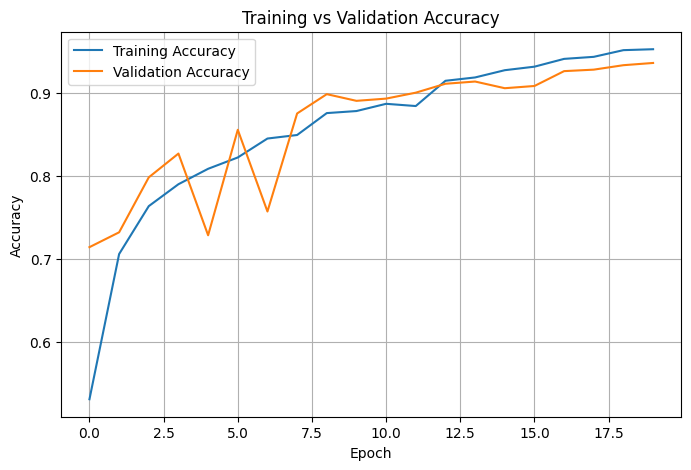

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## 20. Plot Training Loss

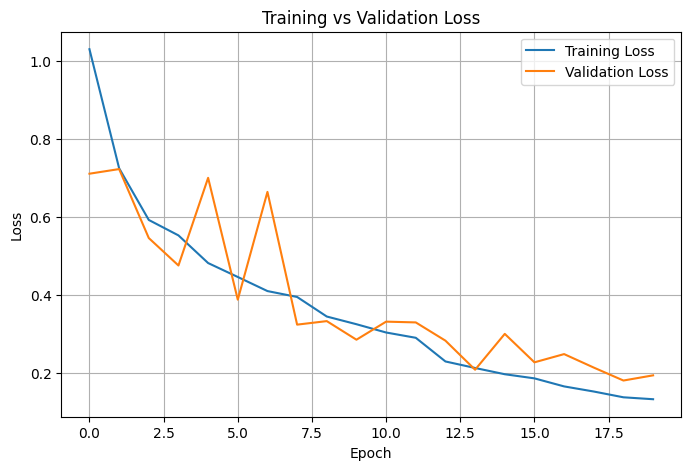

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


## 21. Evaluate on Test Dataset

In [31]:
test_generator.reset()

test_loss, test_accuracy = model.evaluate(
    test_generator
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.8856 - loss: 0.9237
Test Loss     : 0.9237
Test Accuracy : 88.56%


## 22. Save Final Model

In [32]:
final_model_path = MODELS_DIR / "brain_tumor_cnn_final.keras"

model.save(final_model_path)

print("Final model saved to:", final_model_path.resolve())


Final model saved to: C:\Users\khush\OneDrive\Desktop\abc\models\brain_tumor_cnn_final.keras


## Next Steps

After this notebook works correctly:

- Generate confusion matrix
- Calculate precision, recall, and F1-score
- Compare custom CNN with transfer learning
- Add Grad-CAM explainability
- Integrate the saved `.keras` model with Flask
- Build the HTML/CSS result interface
